# Dataset Initial Anaysis

### List files and subfolders

In [32]:
import os
import numpy as np

# Base path
base_dir = "/home/arthur/.cache/kagglehub/datasets/trainingdatapro/cars-video-object-tracking/versions/3"
img_dir = os.path.join(base_dir, "images")
box_dir = os.path.join(base_dir, "boxes")
xml_path = os.path.join(base_dir, "annotations.xml")

for root, dirs, files in os.walk(base_dir):
    print(root)
    for f in files[:5]:
        print("   ", f)



/home/arthur/.cache/kagglehub/datasets/trainingdatapro/cars-video-object-tracking/versions/3
    annotations.xml
/home/arthur/.cache/kagglehub/datasets/trainingdatapro/cars-video-object-tracking/versions/3/boxes
    frame_000109.PNG
    frame_000092.PNG
    frame_000181.PNG
    frame_000202.PNG
    frame_000045.PNG
/home/arthur/.cache/kagglehub/datasets/trainingdatapro/cars-video-object-tracking/versions/3/images
    frame_000109.PNG
    frame_000092.PNG
    frame_000181.PNG
    frame_000202.PNG
    frame_000045.PNG


In [35]:
count = 0
for root, _, files in os.walk(img_dir):
    for f in files:
        count += 1

print(f"Total number of images: {count}")

Total number of images: 301


### Parse and Visualize Bounding Boxes

Found 5 frames with annotations


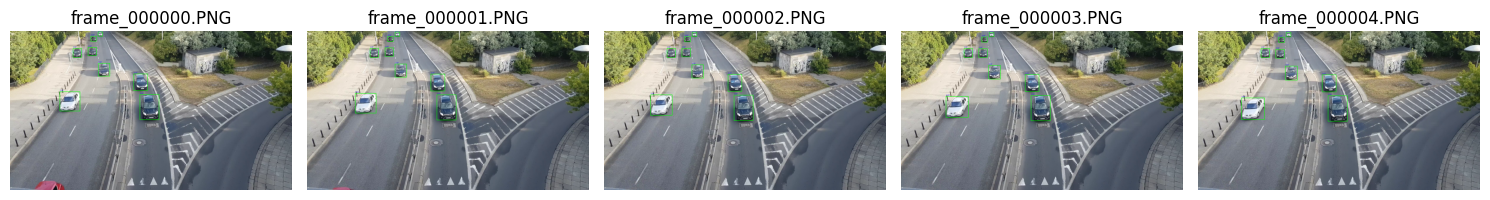

In [ ]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET




# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Extract boxes grouped by frame number
annotations = {}

for track in root.findall("track"):
    label = track.get("label")
    for box in track.findall("box"):
        frame = int(box.get("frame"))
        xtl = float(box.get("xtl"))
        ytl = float(box.get("ytl"))
        xbr = float(box.get("xbr"))
        ybr = float(box.get("ybr"))
        outside = int(box.get("outside"))
        if outside == 1:
            continue  # skip boxes marked as outside
        annotations.setdefault(frame, []).append((label, xtl, ytl, xbr, ybr))

# Choose some frames that actually exist
sample_frames = sorted(list(annotations.keys()))[:5]
print("Found", len(sample_frames), "frames with annotations")

plt.figure(figsize=(15, 10))
for i, frame in enumerate(sample_frames):
    fname = f"frame_{frame:06d}.PNG"
    img_path = os.path.join(img_dir, fname)
    img = cv2.imread(img_path)

    if img is None:
        print("Could not load:", img_path)
        continue

    for (label, xtl, ytl, xbr, ybr) in annotations[frame]:
        cv2.rectangle(img, (int(xtl), int(ytl)), (int(xbr), int(ybr)), (0, 255, 0), 2)
        cv2.putText(img, label, (int(xtl), int(ytl) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(sample_frames), i + 1)
    plt.imshow(img_rgb)
    plt.title(fname)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Show image with boxes provided in the dataset

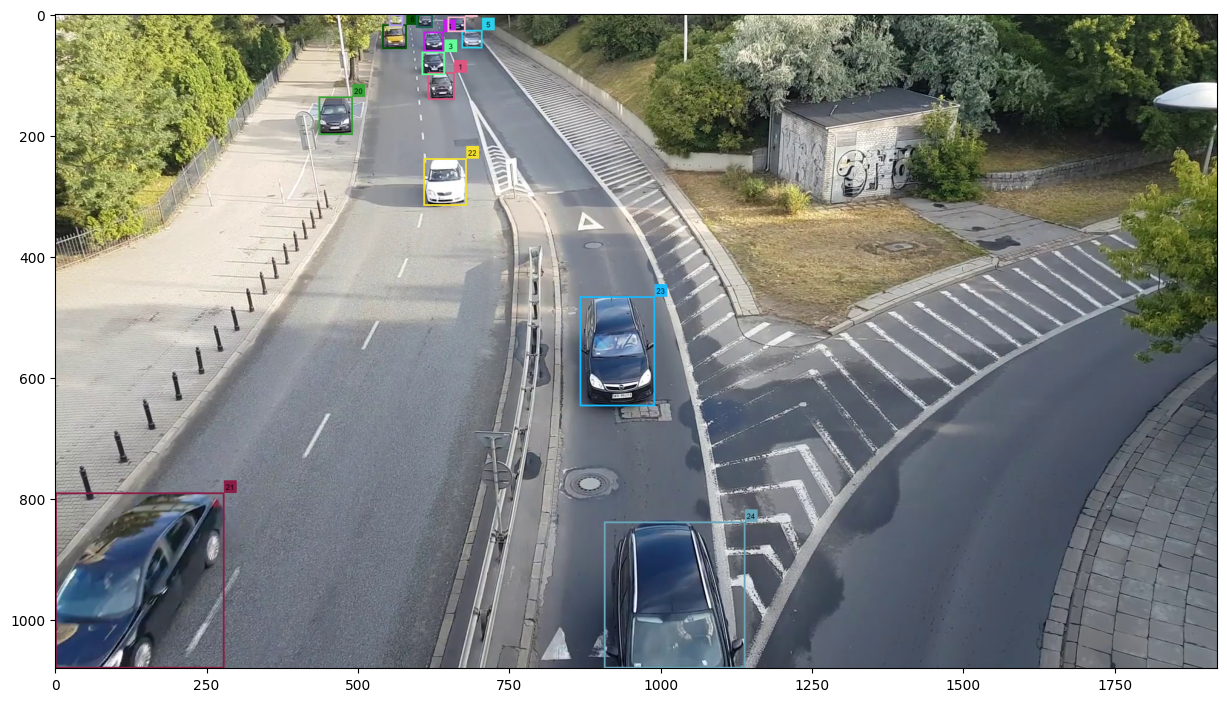

In [ ]:
img = cv2.imread(os.path.join(box_dir, "frame_000109.PNG"))
plt.figure(figsize=(15, 10))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

### Class analysis

In [36]:
# Compute stats
num_classes_per_image = [len(classes) for classes in annotations.values()]
mean_classes = np.mean(num_classes_per_image)

print(f"Mean number of classes per image: {mean_classes:.2f}")
print(f"Total frames analyzed: {len(num_classes_per_image)}")

Mean number of classes per image: 10.72
Total frames analyzed: 901


Class balance:
  car: 9419
  minivan: 240


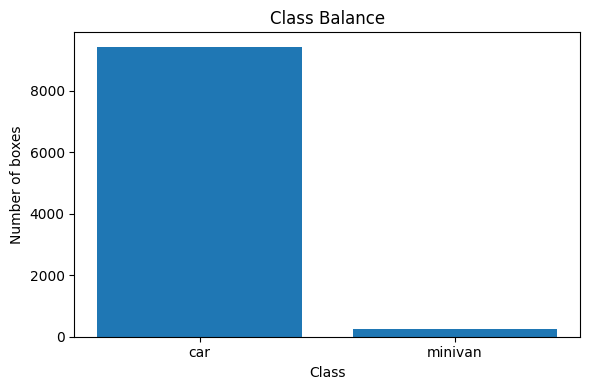

In [38]:
from collections import Counter
# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Count occurrences of each class
class_counts = Counter()

for track in root.findall("track"):
    label = track.get("label")
    for box in track.findall("box"):
        outside = int(box.get("outside"))
        if outside == 1:
            continue
        class_counts[label] += 1

# Print class distribution
print("Class balance:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")

# Optional: visualize as a bar chart
plt.figure(figsize=(6, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of boxes")
plt.title("Class Balance")
plt.tight_layout()
plt.show()